In [1]:
import torch.nn as nn
import torch
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
from torch.utils.data import DataLoader, TensorDataset

In [76]:
def z_normalization(x: np.array):
    mean = np.mean(x, axis=0)
    std = np.std(x, axis=0)
    result = (x - mean) / (std + 1e-8)
    return result

def fancy_output(d: dict):
    for k in d:
        print(f"{k}: {d[k]:.2f}")
    return

def create_seq(x: np.array, y: np.array):
    n = 12
    result_x = []
    res_y = []
    for i in range(x.shape[0] - n):
        result_x.append(x[i:i+n, :].tolist())
        res_y.append(y[i+n])
    return np.array(result_x), np.array(res_y)

def prepare_dy(y: np.array):
    res = y[:-1] - y[:1]
    return res

In [77]:
data1 = pd.read_csv(r"data\ENG.csv")
data2 = pd.read_csv(r"data\RUS.csv")
data3 = pd.read_csv(r"data\USA.csv")
data4 = pd.read_csv(r"data\FRA.csv")
data = pd.concat([data1, data2, data3, data4], ignore_index=True)
gdp_plot = []
def prepare_country_data(df):
    global gdp_plot
    gdp = df["gdp"].values
    gdp_plot.extend(gdp[13:])
    growth = prepare_dy(gdp)
    growth = z_normalization(growth)
    x = df.drop(["gdp", "date", "gdp_per_cap", "consuption", "supply", 
                 "gdp_per_reg", "goverement", "most_popular_party", "flag_name"], axis=1).values[:-1]
    x_z = z_normalization(x)
    return create_seq(x_z, growth)

seq_X = []
seqs_y = []

for df in [data1, data2, data3, data4]:
    x_s, y_s = prepare_country_data(df)
    #y_s = np.tanh(y_s / 2.0) * 2.0

    seq_X.append(x_s)
    seqs_y.append(y_s)

    

X_f = np.concatenate(seq_X, axis=0)
y_f = np.concatenate(seqs_y, axis=0)

X = torch.tensor(X_f, dtype=torch.float32)
y = torch.tensor(y_f, dtype=torch.float32).view(-1, 1)

dataset = TensorDataset(X, y)

train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [78]:
len(gdp_plot)

472

In [79]:
print(X.shape)
print(y.shape)

torch.Size([472, 12, 27])
torch.Size([472, 1])


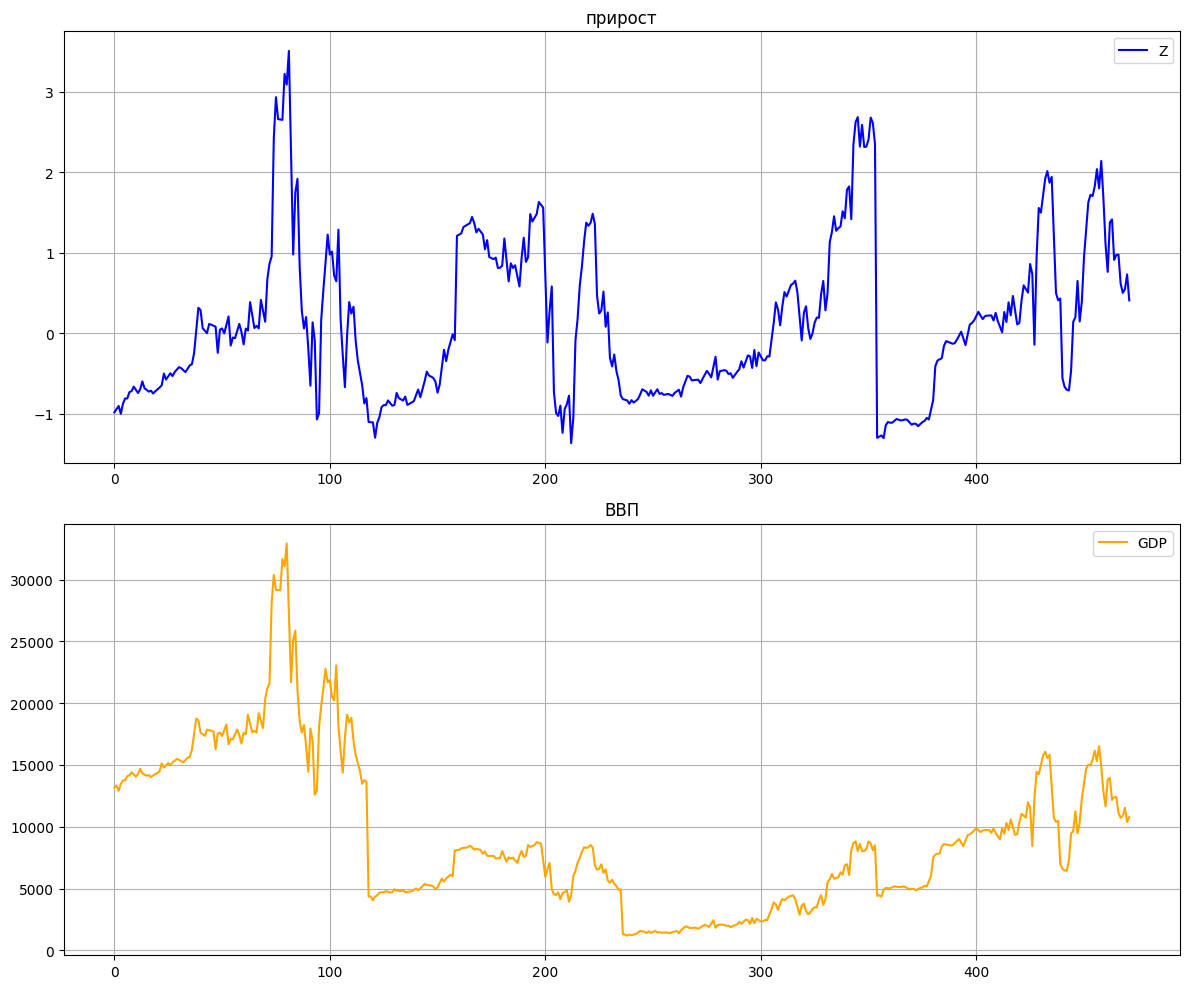

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.plot(y.numpy(), color='blue', label='нормированно')
ax1.set_title('прирост')
ax1.legend()
ax1.grid(True)


#ax2.plot(y.numpy(), color='blue', label='Прирост')
ax2.plot(gdp_plot, color='orange', label='GDP')
ax2.set_title('ВВП')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [8]:
class Model_mem(nn.Module):
    def __init__(self, input_size = 27, hidden = 16, n_l = 2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, n_l, batch_first=True, dropout=0.4)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_step = out[:, -1, :]
        return self.fc(last_step)

In [9]:
model = Model_mem()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-6, weight_decay=1e-4)
criterion = nn.MSELoss()

n_epochs = 3000

In [10]:
for epoch in range(n_epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        prediction = model(batch_X)
        loss = criterion(prediction, batch_y)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(f"Эпоха {epoch}, потери - {loss.item():.4f}")

Эпоха 0, потери - 1.8812
Эпоха 100, потери - 2.6002


KeyboardInterrupt: 

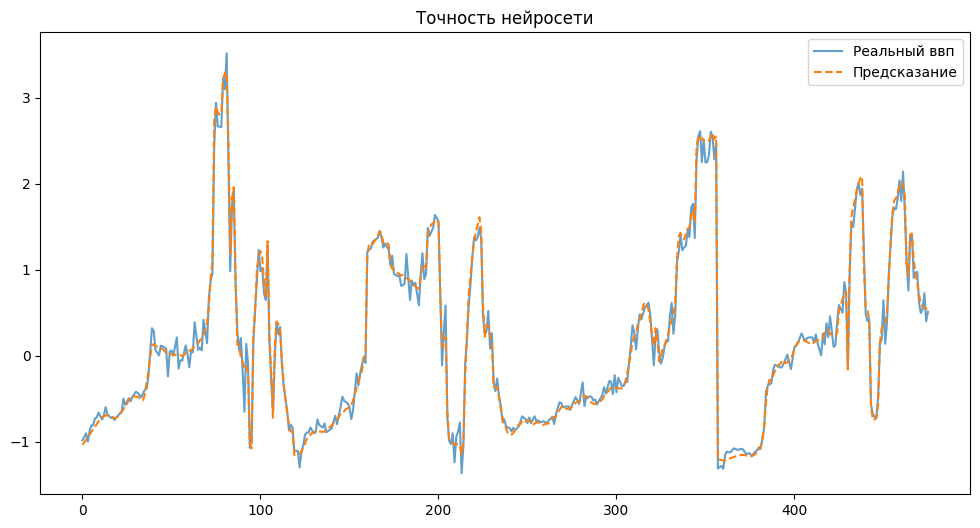

In [ ]:


model.eval()
with torch.no_grad():
    predictions = model(X).numpy()

plt.figure(figsize=(12, 6))
plt.plot(y.numpy(), label='Реальный ввп', alpha=0.7)
plt.plot(predictions, label='Предсказание', linestyle='--')
plt.legend()
plt.title("Точность нейросети")
plt.show()

In [ ]:
data_train = pd.read_csv("data/AUS.csv")
y_np_t = data_train["gdp"].values
X_np_t = data_train.drop(["gdp", "date", "gdp_per_cap", "consuption", "supply", "gdp_per_reg", "goverement", "most_popular_party", "flag_name"], axis=1).values

y_z_t = z_normalization(y_np_t)
X_z_t = z_normalization(X_np_t)

X_z, y_z = create_seq(X_z_t, y_z_t)

X_t = torch.tensor(X_z, dtype=torch.float32)
y_t = torch.tensor(y_z, dtype=torch.float32).view(-1, 1)


In [ ]:
model.eval()
with torch.no_grad():
    predictions = model(X_t).numpy()

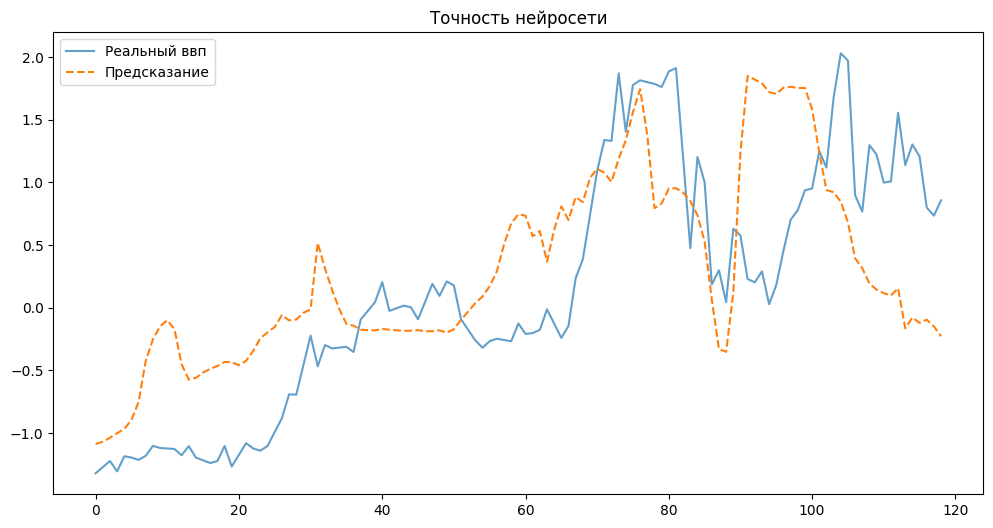

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_t.numpy(), label='Реальный ввп', alpha=0.7)
plt.plot(predictions, label='Предсказание', linestyle='--')
plt.legend()
plt.title("Точность нейросети")
plt.show()